In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("C:/XMUM/2026.04/Advance Data Analytic/project_code/data/diabetic_flat_cleaned.csv")
df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_20408\2942156983.py:13: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/XMUM/2026.04/Advance Data Analytic/project_code/data/diabetic_flat_cleaned.csv")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.shape

(101766, 50)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
missing_df = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (
        df.isna().sum() / len(df) * 100
    ).round(2)
})

missing_df = missing_df[
    missing_df["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df

,Missing Count,Missing Percentage
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [5]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [6]:
readmission_pct = (
    df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(readmission_pct)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


In [7]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

## Target variable readmittes "<30"

In [8]:
df["target"] = (df["readmitted"] == "<30").astype(int)

In [9]:
df["target"].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

In [10]:
columns_to_drop = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "weight",
    "max_glu_serum",
    "A1Cresult"
]

df = df.drop(columns=columns_to_drop)


In [11]:
df.shape

(101766, 45)

In [12]:
numeric_features = df.drop(columns=["target"]).select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_features

['admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses']

In [13]:
# some of numeric features are actually categorical, so we need to remove them from numeric_features list
categorical_id_features = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

numeric_features = [
    col for col in numeric_features
    if col not in categorical_id_features
]

categorical_features = [
    col for col in df.columns
    if col not in numeric_features + ["target"]
]

In [14]:
print("Numerical:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numerical: 8
Categorical: 36


In [15]:
# feature-target split
X = df.drop(columns=["target"])
y = df["target"]

print(X.shape)
print(y.shape)

(101766, 44)
(101766,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
print(X_train.shape)
print(X_test.shape)

(81412, 44)
(20354, 44)


In [18]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [19]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [20]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [21]:
X_train_processed = preprocessor.fit_transform(X_train)

print(X_train_processed.shape)

(81412, 2402)


In [22]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",  # pay more attention to minority class
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [24]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.65      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.77      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354

ROC-AUC: 0.6697023897316968
Confusion Matrix:
[[18076     7]
 [ 2258    13]]


In [25]:
# ROC-AUC is good but the recall is low, which means the model classify many positive samples as negative, we can adjust the threshold to improve recall
threshold = 0.30

y_pred_adjusted = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))
print(confusion_matrix(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.43      0.06      0.11      2271

    accuracy                           0.89     20354
   macro avg       0.66      0.53      0.52     20354
weighted avg       0.84      0.89      0.85     20354

[[17898   185]
 [ 2133   138]]


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.51, 0.02)

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)

    precisions.append(
        precision_score(y_test, preds, zero_division=0)
    )

    recalls.append(
        recall_score(y_test, preds, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_test, preds, zero_division=0)
    )

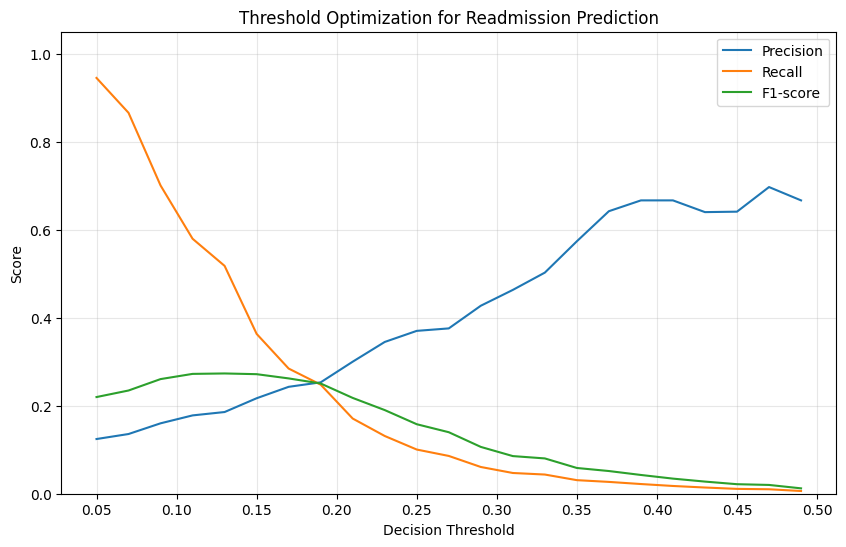

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precisions,
    label="Precision"
)

plt.plot(
    thresholds,
    recalls,
    label="Recall"
)

plt.plot(
    thresholds,
    f1_scores,
    label="F1-score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization for Readmission Prediction")

plt.xticks(np.arange(0.05, 0.55, 0.05))

plt.ylim(0, 1.05)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [28]:
threshold_results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions,
    "recall": recalls,
    "f1_score": f1_scores
})

threshold_results.sort_values(
    by="f1_score",
    ascending=False
).head(10)

,threshold,precision,recall,f1_score
4,0.13,0.185665,0.517834,0.273329
3,0.11,0.178006,0.579480,0.272351
5,0.15,0.216991,0.363276,0.271694
6,0.17,0.242948,0.284456,0.262069
2,0.09,0.160012,0.700572,0.260521
7,0.19,0.253147,0.247908,0.250501
1,0.07,0.135680,0.865698,0.234592
0,0.05,0.124305,0.944958,0.219708
8,0.21,0.300077,0.170850,0.217733
9,0.23,0.344907,0.131220,0.190112


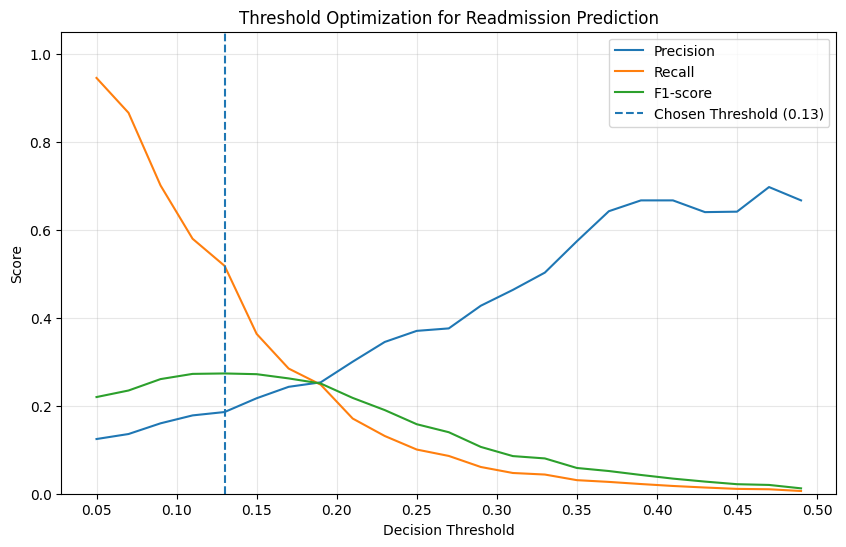

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precisions,
    label="Precision"
)

plt.plot(
    thresholds,
    recalls,
    label="Recall"
)

plt.plot(
    thresholds,
    f1_scores,
    label="F1-score"
)

# highlight chosen threshold
best_t = 0.13
plt.axvline(x=best_t, linestyle="--", label="Chosen Threshold (0.13)")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization for Readmission Prediction")

plt.xticks(np.arange(0.05, 0.55, 0.05))

plt.ylim(0, 1.05)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [30]:
y_pred_best = (y_prob >= best_t).astype(int)

print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.92      0.71      0.81     18083
           1       0.19      0.52      0.27      2271

    accuracy                           0.69     20354
   macro avg       0.55      0.62      0.54     20354
weighted avg       0.84      0.69      0.75     20354

[[12925  5158]
 [ 1095  1176]]


In [31]:
import joblib

joblib.dump(model, "readmitted_model.pkl")

['readmitted_model.pkl']

Feature Importance Analysis

In [32]:
import joblib
import seaborn as sns

pipeline = joblib.load("readmitted_model.pkl")
rf_model = pipeline.named_steps["classifier"]

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

len(feature_names)

2402

In [33]:
importance_df = pd.DataFrame({"feature": feature_names,"importance": rf_model.feature_importances_})
importance_df = importance_df.sort_values(by="importance",ascending=False)

In [34]:
importance_df.head(15)

,feature,importance
1,num__num_lab_procedures,0.046734
3,num__num_medications,0.043522
6,num__number_inpatient,0.037454
0,num__time_in_hospital,0.034686
7,num__number_diagnoses,0.025133
2,num__num_procedures,0.024632
4,num__number_outpatient,0.012542
5,num__number_emergency,0.011731
13,cat__gender_Female,0.010811
14,cat__gender_Male,0.010784


C:\Users\DELL\AppData\Local\Temp\ipykernel_20408\46144812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


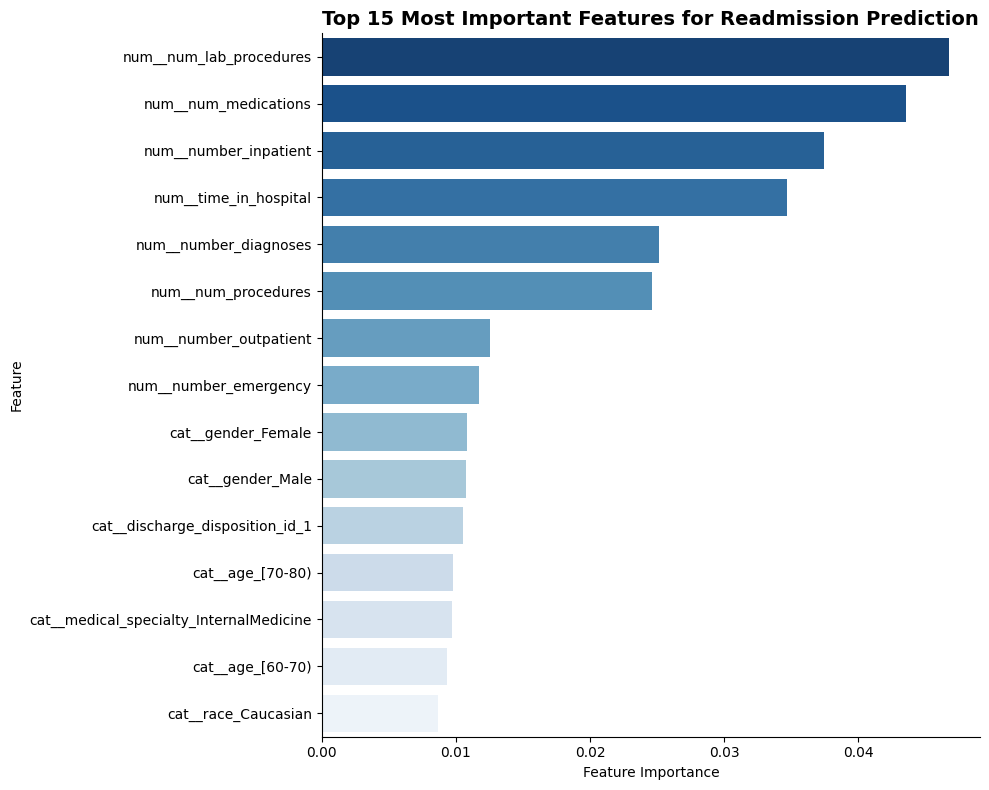

In [35]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title(
    "Top 15 Most Important Features for Readmission Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

sns.despine()

plt.tight_layout()

plt.show()